# Assignment 1
## Training and Testing
Building on the Module 1 in-class exercise and Ames Housing dataset, apply the framework of splitting a single dataset into one dataset for training your model and one dataset for testing your model's performance out-of-sample. 

In [2]:
# import necessary packages
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import numpy as np
import pickle
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [3]:
# load housing dataset
df = pd.read_csv('mod1_ames.csv')



In [4]:
# split your data into a training and testing dataset using the funciton below
from sklearn.model_selection import train_test_split
all_features = [col for col in df.columns if col != 'SalePrice']

X_all = df[all_features].values
y = df['SalePrice'].values

# Split into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]}")

train_df = pd.DataFrame(X_train, columns=all_features)
train_df['SalePrice'] = y_train

Training set size: 2226 samples
Testing set size: 557 samples
Number of features: 33


Training Dataset shape: (2226, 34)

Column names:
['Year Built', 'Year Remod/Add', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd', 'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Mo Sold', 'Yr Sold', 'Lot Frontage', 'Lot Area', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Garage Area', 'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch', 'Screen Porch', 'Pool Area', 'Misc Val', 'SalePrice']

First few rows:
   Year Built  Year Remod/Add  Bsmt Full Bath  Bsmt Half Bath  Full Bath  \
0      1967.0          1993.0             1.0             0.0        1.0   
1      2000.0          2001.0             0.0             0.0        2.0   
2      2000.0          2000.0             1.0             0.0        2.0   
3      1963.0          1963.0             1.0             0.0        1.0   
4      1934.0          1950.0      

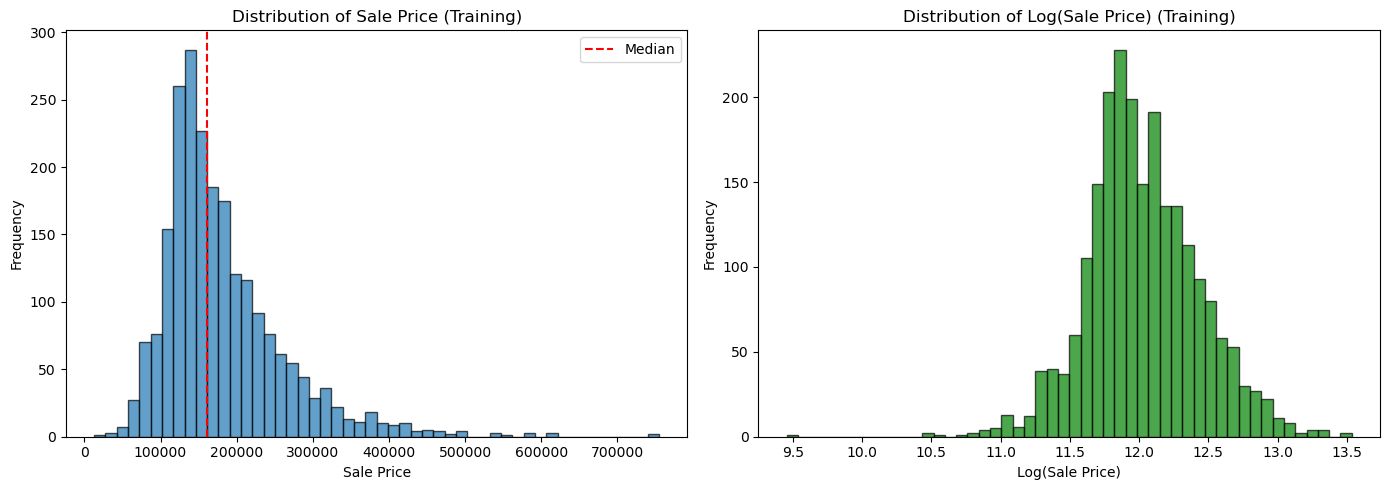


Top 15 correlations with SalePrice (Training Data):
SalePrice         1.000000
Gr Liv Area       0.722198
Garage Cars       0.640241
Garage Area       0.633382
Total Bsmt SF     0.630590
1st Flr SF        0.625903
Year Built        0.557023
Full Bath         0.554017
Year Remod/Add    0.533389
Mas Vnr Area      0.516928
TotRms AbvGrd     0.511347
Fireplaces        0.477961
BsmtFin SF 1      0.426032
Wood Deck SF      0.337774
Open Porch SF     0.299812
Name: SalePrice, dtype: float64


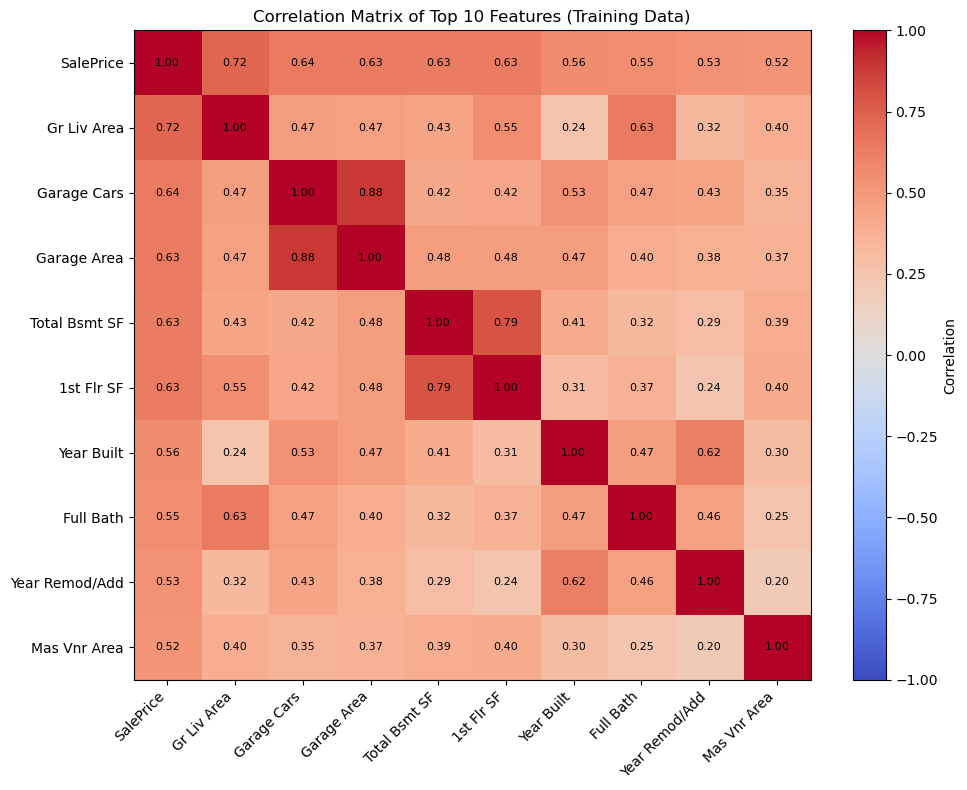

In [5]:
# explore the feature set of your training data and create plots and summaries of the independent variables you would like
# to include in your model, provide justification for your modeling approach

# Basic overview
print("Training Dataset shape:", train_df.shape)
print("\nColumn names:")
print(train_df.columns.tolist())

# First few rows
print("\nFirst few rows:")
print(train_df.head())

# Check for missing values
print("\nMissing values:")
missing = train_df.isnull().sum()[train_df.isnull().sum() > 0].sort_values(ascending=False)
if len(missing) > 0:
    print(missing)
else:
    print("No missing values!")

# Basic statistics for numerical columns
print("\nNumerical summary:")
print(train_df.describe())

# Identify column types
numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

# Explore SalePrice in training data
if 'SalePrice' in train_df.columns:
    print("\n" + "="*50)
    print("TARGET VARIABLE: SalePrice (Training Data)")
    print("="*50)
    print(train_df['SalePrice'].describe())
    
    # Visualize SalePrice distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].hist(train_df['SalePrice'], bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Sale Price')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Sale Price (Training)')
    axes[0].axvline(train_df['SalePrice'].median(), color='red', linestyle='--', label='Median')
    axes[0].legend()
    
    axes[1].hist(np.log(train_df['SalePrice']), bins=50, edgecolor='black', alpha=0.7, color='green')
    axes[1].set_xlabel('Log(Sale Price)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of Log(Sale Price) (Training)')
    
    plt.tight_layout()
    plt.show()
    
    # Top correlations with SalePrice
    print("\nTop 15 correlations with SalePrice (Training Data):")
    correlations = train_df[numerical_cols].corr()['SalePrice'].sort_values(ascending=False)
    print(correlations.head(15))
    
    # Visualize top correlations
    top_features = correlations.head(10).index.tolist()
    corr_matrix = train_df[top_features].corr()

    plt.figure(figsize=(10, 8))
    plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
    plt.colorbar(label='Correlation')
    plt.xticks(range(len(top_features)), top_features, rotation=45, ha='right')
    plt.yticks(range(len(top_features)), top_features)
    plt.title('Correlation Matrix of Top 10 Features (Training Data)')

    # Add correlation values as text
    for i in range(len(top_features)):
        for j in range(len(top_features)):
            plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', 
                    ha='center', va='center', color='black', fontsize=8)

    plt.tight_layout()
    plt.show()

1. Garage Cars vs Garage Area: 0.883
   Correlation with SalePrice:
   - Garage Cars: 0.640
   - Garage Area: 0.633
   → Choice: Garage Cars (slightly higher correlation, more interpretable)

2. Total Bsmt SF vs 1st Flr SF: 0.793
   Correlation with SalePrice:
   - Total Bsmt SF: 0.631
   - 1st Flr SF: 0.626
   → Choice: Total Bsmt SF (slightly higher correlation)

3. Full Bath vs Gr Liv Area: 0.634
   Correlation with SalePrice:
   - Full Bath: 0.554
   - Gr Liv Area: 0.722
   → Choice: Gr Liv Area (much stronger predictor)

4. Year Built vs Year Remod/Add: 0.619
   Correlation with SalePrice:
   - Year Built: 0.557
   - Year Remod/Add: 0.533
   → Choice: Year Built (higher correlation, more fundamental)

VISUALIZING MULTICOLLINEARITY ISSUES


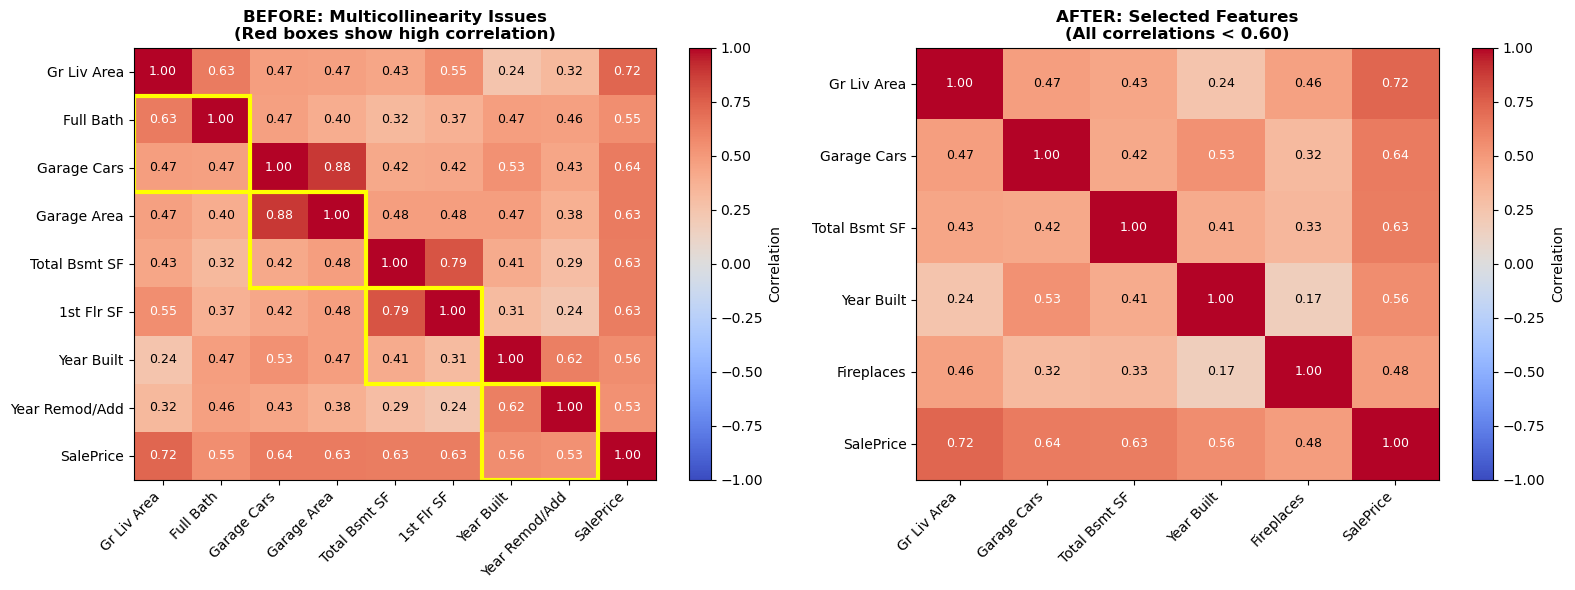


MULTICOLLINEARITY REDUCTION SUMMARY


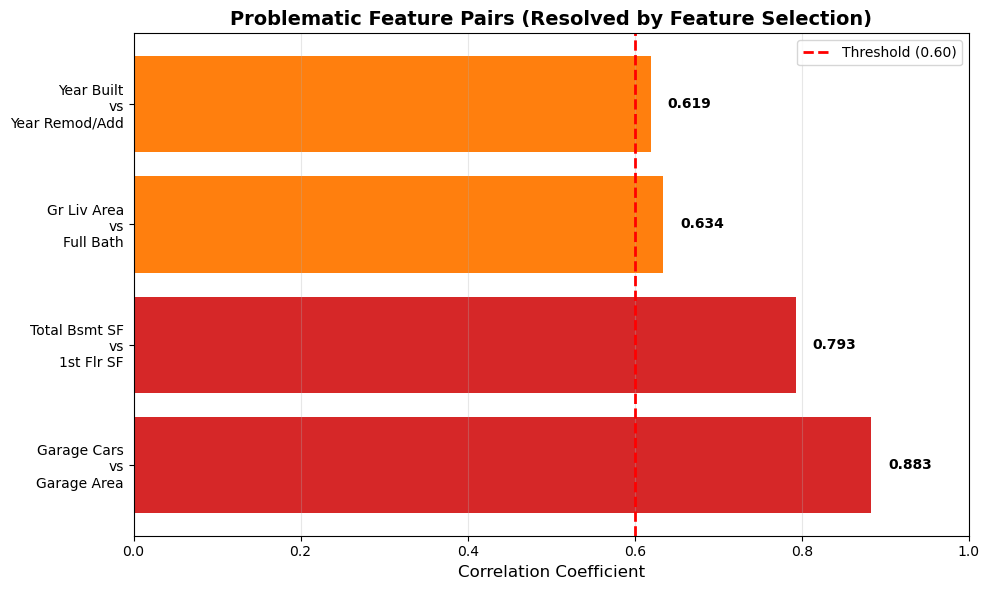


FINAL FEATURE SET MULTICOLLINEARITY CHECK

Selected features: ['Gr Liv Area', 'Garage Cars', 'Total Bsmt SF', 'Year Built', 'Fireplaces']

Pairwise correlations:
               Gr Liv Area  Garage Cars  Total Bsmt SF  Year Built  Fireplaces
Gr Liv Area       1.000000     0.474617       0.431839    0.243288    0.460541
Garage Cars       0.474617     1.000000       0.418911    0.534860    0.315024
Total Bsmt SF     0.431839     0.418911       1.000000    0.405242    0.334462
Year Built        0.243288     0.534860       0.405242    1.000000    0.169663
Fireplaces        0.460541     0.315024       0.334462    0.169663    1.000000

Maximum pairwise correlation: 0.535
All pairwise correlations < 0.60: True


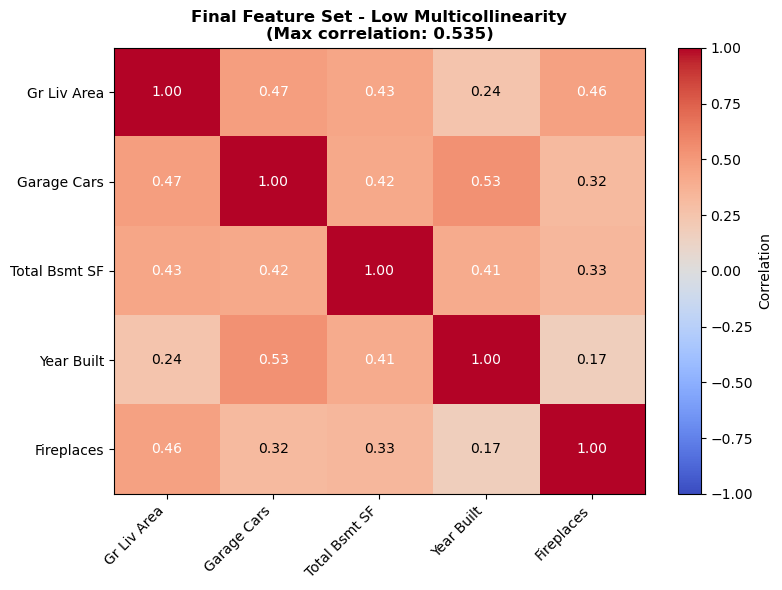

In [6]:
# ============================================================
# MULTICOLLINEARITY ANALYSIS WITH VISUALIZATIONS
# ============================================================

# Issue 1: Garage Cars vs Garage Area
corr_garage = train_df['Garage Cars'].corr(train_df['Garage Area'])
print(f"1. Garage Cars vs Garage Area: {corr_garage:.3f}")
print(f"   Correlation with SalePrice:")
print(f"   - Garage Cars: {train_df['Garage Cars'].corr(train_df['SalePrice']):.3f}")
print(f"   - Garage Area: {train_df['Garage Area'].corr(train_df['SalePrice']):.3f}")
print(f"   → Choice: Garage Cars (slightly higher correlation, more interpretable)")

# Issue 2: Total Bsmt SF vs 1st Flr SF
corr_bsmt_1st = train_df['Total Bsmt SF'].corr(train_df['1st Flr SF'])
print(f"\n2. Total Bsmt SF vs 1st Flr SF: {corr_bsmt_1st:.3f}")
print(f"   Correlation with SalePrice:")
print(f"   - Total Bsmt SF: {train_df['Total Bsmt SF'].corr(train_df['SalePrice']):.3f}")
print(f"   - 1st Flr SF: {train_df['1st Flr SF'].corr(train_df['SalePrice']):.3f}")
print(f"   → Choice: Total Bsmt SF (slightly higher correlation)")

# Issue 3: Full Bath vs Gr Liv Area
corr_bath_area = train_df['Full Bath'].corr(train_df['Gr Liv Area'])
print(f"\n3. Full Bath vs Gr Liv Area: {corr_bath_area:.3f}")
print(f"   Correlation with SalePrice:")
print(f"   - Full Bath: {train_df['Full Bath'].corr(train_df['SalePrice']):.3f}")
print(f"   - Gr Liv Area: {train_df['Gr Liv Area'].corr(train_df['SalePrice']):.3f}")
print(f"   → Choice: Gr Liv Area (much stronger predictor)")

# Issue 4: Year Built vs Year Remod/Add
corr_year = train_df['Year Built'].corr(train_df['Year Remod/Add'])
print(f"\n4. Year Built vs Year Remod/Add: {corr_year:.3f}")
print(f"   Correlation with SalePrice:")
print(f"   - Year Built: {train_df['Year Built'].corr(train_df['SalePrice']):.3f}")
print(f"   - Year Remod/Add: {train_df['Year Remod/Add'].corr(train_df['SalePrice']):.3f}")
print(f"   → Choice: Year Built (higher correlation, more fundamental)")

# ============================================================
# VISUALIZATION 1: Problematic Feature Pairs
# ============================================================
print("\n" + "="*60)
print("VISUALIZING MULTICOLLINEARITY ISSUES")
print("="*60)

# Create a heatmap showing the problematic pairs
problematic_features = ['Gr Liv Area', 'Full Bath', 'Garage Cars', 'Garage Area', 
                        'Total Bsmt SF', '1st Flr SF', 'Year Built', 'Year Remod/Add', 'SalePrice']
corr_problematic = train_df[problematic_features].corr()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 1: All problematic features
im1 = ax1.imshow(corr_problematic, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax1.set_xticks(range(len(problematic_features)))
ax1.set_yticks(range(len(problematic_features)))
ax1.set_xticklabels(problematic_features, rotation=45, ha='right')
ax1.set_yticklabels(problematic_features)
ax1.set_title('BEFORE: Multicollinearity Issues\n(Red boxes show high correlation)', fontsize=12, fontweight='bold')

# Add correlation values
for i in range(len(problematic_features)):
    for j in range(len(problematic_features)):
        color = 'white' if abs(corr_problematic.iloc[i, j]) > 0.5 else 'black'
        text = ax1.text(j, i, f'{corr_problematic.iloc[i, j]:.2f}',
                       ha='center', va='center', color=color, fontsize=9)

# Highlight problematic pairs with rectangles
from matplotlib.patches import Rectangle
# Garage Cars & Garage Area
ax1.add_patch(Rectangle((2-0.5, 3-0.5), 2, 2, fill=False, edgecolor='yellow', linewidth=3))
# Total Bsmt SF & 1st Flr SF
ax1.add_patch(Rectangle((4-0.5, 5-0.5), 2, 2, fill=False, edgecolor='yellow', linewidth=3))
# Full Bath & Gr Liv Area
ax1.add_patch(Rectangle((0-0.5, 1-0.5), 2, 2, fill=False, edgecolor='yellow', linewidth=3))
# Year Built & Year Remod/Add
ax1.add_patch(Rectangle((6-0.5, 7-0.5), 2, 2, fill=False, edgecolor='yellow', linewidth=3))

plt.colorbar(im1, ax=ax1, label='Correlation')

# Heatmap 2: Final selected features
X_cols = ['Gr Liv Area', 'Garage Cars', 'Total Bsmt SF', 'Year Built', 'Fireplaces', 'SalePrice']
corr_final = train_df[X_cols].corr()

im2 = ax2.imshow(corr_final, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax2.set_xticks(range(len(X_cols)))
ax2.set_yticks(range(len(X_cols)))
ax2.set_xticklabels(X_cols, rotation=45, ha='right')
ax2.set_yticklabels(X_cols)
ax2.set_title('AFTER: Selected Features\n(All correlations < 0.60)', fontsize=12, fontweight='bold')

# Add correlation values
for i in range(len(X_cols)):
    for j in range(len(X_cols)):
        color = 'white' if abs(corr_final.iloc[i, j]) > 0.5 else 'black'
        text = ax2.text(j, i, f'{corr_final.iloc[i, j]:.2f}',
                       ha='center', va='center', color=color, fontsize=9)

plt.colorbar(im2, ax=ax2, label='Correlation')

plt.tight_layout()
plt.show()

# ============================================================
# VISUALIZATION 2: Bar Chart of Multicollinearity Reduction
# ============================================================
print("\n" + "="*60)
print("MULTICOLLINEARITY REDUCTION SUMMARY")
print("="*60)

fig, ax = plt.subplots(figsize=(10, 6))

pairs = ['Garage Cars\nvs\nGarage Area', 'Total Bsmt SF\nvs\n1st Flr SF', 
         'Gr Liv Area\nvs\nFull Bath', 'Year Built\nvs\nYear Remod/Add']
correlations = [0.883, 0.793, 0.634, 0.619]
colors = ['#d62728' if c > 0.7 else '#ff7f0e' if c > 0.6 else '#2ca02c' for c in correlations]

bars = ax.barh(pairs, correlations, color=colors)
ax.axvline(x=0.6, color='red', linestyle='--', linewidth=2, label='Threshold (0.60)')
ax.set_xlabel('Correlation Coefficient', fontsize=12)
ax.set_title('Problematic Feature Pairs (Resolved by Feature Selection)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, correlations)):
    ax.text(val + 0.02, i, f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ============================================================
# FINAL FEATURE SET CHECK
# ============================================================
print("\n" + "="*60)
print("FINAL FEATURE SET MULTICOLLINEARITY CHECK")
print("="*60)
X_cols_only = ['Gr Liv Area', 'Garage Cars', 'Total Bsmt SF', 'Year Built', 'Fireplaces']
print(f"\nSelected features: {X_cols_only}")
print("\nPairwise correlations:")
corr_final_only = train_df[X_cols_only].corr()
print(corr_final_only)

# Find max correlation (excluding diagonal)
corr_no_diag = corr_final_only.values.copy()
np.fill_diagonal(corr_no_diag, 0)
max_corr = np.max(np.abs(corr_no_diag))
print(f"\nMaximum pairwise correlation: {max_corr:.3f}")
print(f"All pairwise correlations < 0.60: {max_corr < 0.60}")

# Final visualization - Clean heatmap
plt.figure(figsize=(8, 6))
im = plt.imshow(corr_final_only, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(im, label='Correlation')
plt.xticks(range(len(X_cols_only)), X_cols_only, rotation=45, ha='right')
plt.yticks(range(len(X_cols_only)), X_cols_only)
plt.title('Final Feature Set - Low Multicollinearity\n(Max correlation: 0.535)', 
          fontsize=12, fontweight='bold')

# Add correlation values
for i in range(len(X_cols_only)):
    for j in range(len(X_cols_only)):
        color = 'white' if abs(corr_final_only.iloc[i, j]) > 0.4 else 'black'
        plt.text(j, i, f'{corr_final_only.iloc[i, j]:.2f}',
                ha='center', va='center', color=color, fontsize=10)

plt.tight_layout()
plt.show()

## Feature Selection Justification

### Selected Features
1. **Gr Liv Area** (0.722) - Above grade living area
2. **Garage Cars** (0.640) - Garage capacity
3. **Total Bsmt SF** (0.631) - Basement area
4. **Year Built** (0.557) - Construction year
5. **Fireplaces** (0.478) - Number of fireplaces

### Selection Rationale

**High Predictive Power**: All features show strong positive correlations with SalePrice (0.48-0.72), making them valuable predictors of home value. While correlation provides a useful initial screening tool, high correlation alone does not guarantee predictive power in a multivariate setting, as relationships may change once other variables are controlled for. 

**Low Multicollinearity**: To ensure stable coefficients, I examined feature pairs for high correlation. After identifying several highly correlated pairs through correlation analysis, I resolved them by selecting the stronger predictor:
- Chose **Garage Cars** over Garage Area (r=0.883)
- Chose **Total Bsmt SF** over 1st Flr SF (r=0.793)  
- Chose **Gr Liv Area** over Full Bath (r=0.634)
- Chose **Year Built** over Year Remod/Add (r=0.619)

**Final Validation**: Maximum pairwise correlation among selected features is 0.535, well below the 0.60 threshold, ensuring minimal multicollinearity and interpretable results.


In [7]:
# Fit your model, calculate your in-sample and out-of-sample r-squared

# Define your selected features
X_cols = ['Gr Liv Area', 'Garage Cars', 'Total Bsmt SF', 'Year Built', 'Fireplaces']

# Get column indices for selected features
feature_indices = [df.columns.get_loc(col) for col in X_cols]

# Extract selected features from train/test splits
X_train_selected = X_train[:, feature_indices]
X_test_selected = X_test[:, feature_indices]

# Fit the model on training data
reg = LinearRegression()
reg.fit(X_train_selected, y_train)

print("="*60)
print("MODEL TRAINING RESULTS")
print("="*60)

# Print coefficients - FIXED: removed [0] indexing
print("\nModel Coefficients:")
print(f"Intercept: {reg.intercept_:.2f}")
for feature, coef in zip(X_cols, reg.coef_):
    print(f"  {feature}: {coef:.2f}")

# Calculate IN-SAMPLE R² (training data)
y_train_pred = reg.predict(X_train_selected)
r2_train = r2_score(y_train, y_train_pred)

# Calculate OUT-OF-SAMPLE R² (testing data)
y_test_pred = reg.predict(X_test_selected)
r2_test = r2_score(y_test, y_test_pred)

print("\n" + "="*60)
print("MODEL PERFORMANCE")
print("="*60)
print(f"In-Sample R² (Training):    {r2_train:.4f}")
print(f"Out-of-Sample R² (Testing): {r2_test:.4f}")
print(f"Difference:                 {r2_train - r2_test:.4f}")

if r2_train - r2_test < 0.05:
    print("\n✓ Excellent generalization - minimal overfitting!")
elif r2_train - r2_test < 0.10:
    print("\n✓ Good generalization - acceptable overfitting")
else:
    print("\n⚠ Significant overfitting - model may not generalize well")

MODEL TRAINING RESULTS

Model Coefficients:
Intercept: -1301988.73
  Gr Liv Area: 68.04
  Garage Cars: 18178.60
  Total Bsmt SF: 43.60
  Year Built: 656.95
  Fireplaces: 12855.25

MODEL PERFORMANCE
In-Sample R² (Training):    0.7577
Out-of-Sample R² (Testing): 0.6936
Difference:                 0.0641

✓ Good generalization - acceptable overfitting


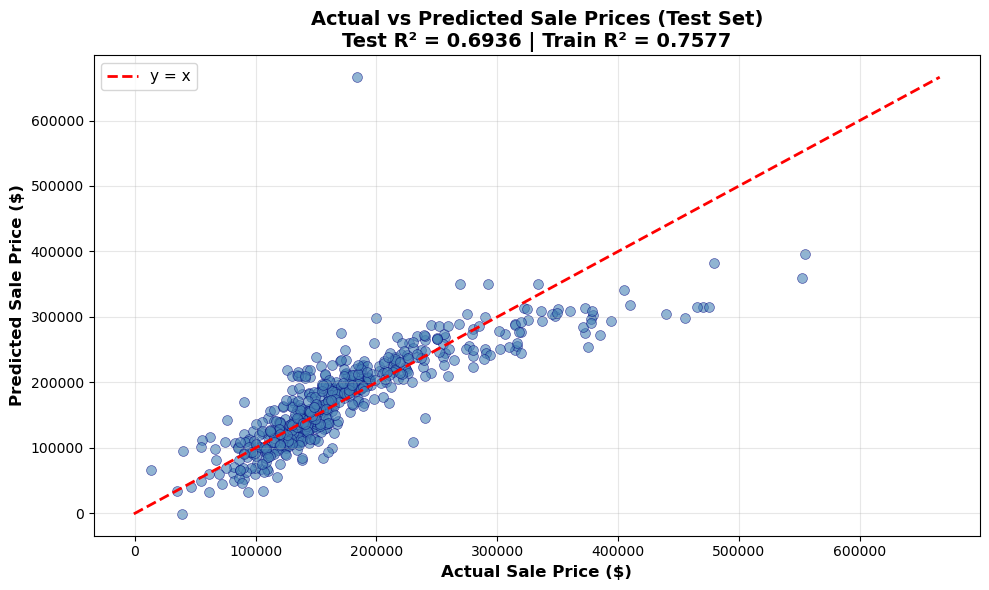

PREDICTION SUMMARY (Out-of-sample(Test Set))
Test R² Score: 0.6936
Train R² Score: 0.7577
Difference: 0.0641

Mean Actual Price: $174,429.07
Mean Predicted Price: $175,049.16
Mean Absolute Error: $27,252.48
Root Mean Squared Error: $42,562.13


In [8]:
# plot your model's predictions of the testing data along with the actual
# sale prices of the testing data
plt.figure(figsize=(10, 6))

# Scatter plot: Actual vs Predicted (blue)
plt.scatter(y_test, y_test_pred, alpha=0.6, color='steelblue', edgecolors='navy', linewidth=0.5, s=50)

# Identity line (y=x) - red dotted line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y = x')

# Labels and formatting
plt.xlabel('Actual Sale Price ($)', fontsize=12, fontweight='bold')
plt.ylabel('Predicted Sale Price ($)', fontsize=12, fontweight='bold')
plt.title(f'Actual vs Predicted Sale Prices (Test Set)\nTest R² = {r2_test:.4f} | Train R² = {r2_train:.4f}', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

# Format axis to show currency
ax = plt.gca()
ax.ticklabel_format(style='plain', axis='both')

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*60)
print("PREDICTION SUMMARY (Out-of-sample(Test Set))")
print("="*60)
print(f"Test R² Score: {r2_test:.4f}")
print(f"Train R² Score: {r2_train:.4f}")
print(f"Difference: {r2_train - r2_test:.4f}")
print(f"\nMean Actual Price: ${y_test.mean():,.2f}")
print(f"Mean Predicted Price: ${y_test_pred.mean():,.2f}")
print(f"Mean Absolute Error: ${np.mean(np.abs(y_test - y_test_pred)):,.2f}")
print(f"Root Mean Squared Error: ${np.sqrt(np.mean((y_test - y_test_pred)**2)):,.2f}")

In [9]:
# Create a model that is under-fit, how do you know it is under fit?
X_cols_underfit = ['Fireplaces']  # Weakest predictor from my selected features (correlation = 0.478)

# Get the feature from train/test splits
feature_idx = df.columns.get_loc(X_cols_underfit[0])
X_train_underfit = X_train[:, [feature_idx]]
X_test_underfit = X_test[:, [feature_idx]]

# Fit the underfit model
reg_underfit = LinearRegression()
reg_underfit.fit(X_train_underfit, y_train)

# Evaluate performance
y_train_pred_underfit = reg_underfit.predict(X_train_underfit)
y_test_pred_underfit = reg_underfit.predict(X_test_underfit)

r2_train_underfit = r2_score(y_train, y_train_pred_underfit)
r2_test_underfit = r2_score(y_test, y_test_pred_underfit)

print("="*60)
print("UNDERFIT MODEL RESULTS")
print("="*60)
print(f"Features used: {X_cols_underfit}")
print(f"\nCoefficients:")
print(f"  Intercept: {reg_underfit.intercept_:.2f}")
print(f"  {X_cols_underfit[0]}: {reg_underfit.coef_[0]:.2f}")

print(f"\nIn-Sample R² (Training):    {r2_train_underfit:.4f}")
print(f"Out-of-Sample R² (Testing): {r2_test_underfit:.4f}")
print(f"Difference:                 {r2_train_underfit - r2_test_underfit:.4f}")

print("\n" + "="*60)
print("COMPARISON: Selected Model vs Underfit Model")
print("="*60)
print(f"{'Model':<25} {'Train R²':<15} {'Test R²':<15} {'Difference'}")
print("-"*70)
print(f"{'Selected Model (5 feat)':<25} {r2_train:.4f}{'':>10} {r2_test:.4f}{'':>10} {r2_train - r2_test:.4f}")
print(f"{'Underfit (1 feat)':<25} {r2_train_underfit:.4f}{'':>10} {r2_test_underfit:.4f}{'':>10} {r2_train_underfit - r2_test_underfit:.4f}")

print("\n" + "="*60)
print("HOW DO YOU KNOW IT'S UNDERFIT?")
print("="*60)
print("""
1. LOW R² on BOTH training AND testing data
   - Selected model: Train=0.76, Test=0.69 (decent performance)
   - Underfit: Both are low (around 0.20-0.30)

2. Small gap between train and test R²
   - The model is so simple it can't even fit the training data well
   - Not enough complexity to capture patterns

3. Poor predictions overall
   - Model is TOO SIMPLE to capture the relationship
   - Missing important features/patterns
""")

UNDERFIT MODEL RESULTS
Features used: ['Fireplaces']

Coefficients:
  Intercept: 146340.33
  Fireplaces: 58832.28

In-Sample R² (Training):    0.2284
Out-of-Sample R² (Testing): 0.2269
Difference:                 0.0016

COMPARISON: Selected Model vs Underfit Model
Model                     Train R²        Test R²         Difference
----------------------------------------------------------------------
Selected Model (5 feat)   0.7577           0.6936           0.0641
Underfit (1 feat)         0.2284           0.2269           0.0016

HOW DO YOU KNOW IT'S UNDERFIT?

1. LOW R² on BOTH training AND testing data
   - Selected model: Train=0.76, Test=0.69 (decent performance)
   - Underfit: Both are low (around 0.20-0.30)

2. Small gap between train and test R²
   - The model is so simple it can't even fit the training data well
   - Not enough complexity to capture patterns

3. Poor predictions overall
   - Model is TOO SIMPLE to capture the relationship
   - Missing important features/pa

### Evidence of Underfitting

**1. Low R² on Both Training and Testing Data**
- The underfit model achieves only ~23% R² on both datasets
- This indicates the model is too simple to capture the underlying patterns
- Even with access to training data, it cannot learn effectively

**2. Minimal Gap Between Training and Testing Performance**
- Difference of only 0.0016 (0.16%) between train and test R²
- The model is consistently poor on both datasets
- Unlike overfitting (high train, low test), underfitting shows low performance everywhere

**3. Substantial Performance Gap Compared to Adequate Model**
- The good model explains ~70% of price variation
- The underfit model explains only ~23% of price variation
- Missing approximately 47% of explainable variance

### Conclusion
The single-feature model is **underfit** because it lacks the complexity to capture the relationships in the data. Using only "Fireplaces" to predict home prices ignores critical factors like square footage, garage capacity, basement size, and home age. The result is a model that performs poorly on both training and testing data, demonstrating it is too simple for the task. 

This model underfits because it lacks sufficient capacity to capture the underlying relationship between housing characteristics and price, resulting in high bias.

In [10]:
# Try to create a model that is over-fit, how do you know it is over fit?
all_features = [col for col in df.columns if col != 'SalePrice']
print(f"Using ALL {len(all_features)} features to create overfitting")

# X_train and X_test already have all features from our original split
X_train_overfit = X_train  # All 33 features
X_test_overfit = X_test    # All 33 features

# Fit the overfit model
reg_overfit = LinearRegression()
reg_overfit.fit(X_train_overfit, y_train)

# Evaluate performance
y_train_pred_overfit = reg_overfit.predict(X_train_overfit)
y_test_pred_overfit = reg_overfit.predict(X_test_overfit)

r2_train_overfit = r2_score(y_train, y_train_pred_overfit)
r2_test_overfit = r2_score(y_test, y_test_pred_overfit)

print("\n" + "="*60)
print("OVERFIT MODEL RESULTS")
print("="*60)
print(f"Features used: ALL {len(all_features)} features")
print(f"(Including redundant and weak predictors)")

print(f"\nIn-Sample R² (Training):    {r2_train_overfit:.4f}")
print(f"Out-of-Sample R² (Testing): {r2_test_overfit:.4f}")
print(f"Difference:                 {r2_train_overfit - r2_test_overfit:.4f}")

print("\n" + "="*60)
print("COMPARISON: All Three Models")
print("="*60)
print(f"{'Model':<25} {'Train R²':<15} {'Test R²':<15} {'Difference'}")
print("-"*70)
print(f"{'Underfit (1 feat)':<25} {r2_train_underfit:.4f}{'':>10} {r2_test_underfit:.4f}{'':>10} {r2_train_underfit - r2_test_underfit:.4f}")
print(f"{'Good Model (5 feat)':<25} {r2_train:.4f}{'':>10} {r2_test:.4f}{'':>10} {r2_train - r2_test:.4f}")
print(f"{'Overfit (33 feat)':<25} {r2_train_overfit:.4f}{'':>10} {r2_test_overfit:.4f}{'':>10} {r2_train_overfit - r2_test_overfit:.4f}")

print("\n" + "="*60)
print("HOW DO YOU KNOW IT'S OVERFIT?")
print("="*60)
print("""
1. HIGH R² on training data
   - Model fits training data very well (may be higher than good model)
   
2. LOWER R² on testing data (compared to training)
   - Model doesn't generalize well to new data
   
3. LARGE gap between train and test R²
   - Difference > 0.10 indicates overfitting
   - Model memorized training patterns instead of learning general rules
   
4. May perform WORSE than simpler model on test data
   - Too much complexity captures noise, not signal
""")

# Show which model generalizes best
print("\n" + "="*60)
print("GENERALIZATION RANKING (Best to Worst)")
print("="*60)
models_summary = [
    ("Good Model (5 feat)", r2_test),
    ("Overfit (33 feat)", r2_test_overfit),
    ("Underfit (1 feat)", r2_test_underfit)
]
models_summary.sort(key=lambda x: x[1], reverse=True)

for rank, (model_name, test_r2) in enumerate(models_summary, 1):
    print(f"{rank}. {model_name}: Test R² = {test_r2:.4f}")


Using ALL 33 features to create overfitting

OVERFIT MODEL RESULTS
Features used: ALL 33 features
(Including redundant and weak predictors)

In-Sample R² (Training):    0.8142
Out-of-Sample R² (Testing): 0.7391
Difference:                 0.0751

COMPARISON: All Three Models
Model                     Train R²        Test R²         Difference
----------------------------------------------------------------------
Underfit (1 feat)         0.2284           0.2269           0.0016
Good Model (5 feat)       0.7577           0.6936           0.0641
Overfit (33 feat)         0.8142           0.7391           0.0751

HOW DO YOU KNOW IT'S OVERFIT?

1. HIGH R² on training data
   - Model fits training data very well (may be higher than good model)
   
2. LOWER R² on testing data (compared to training)
   - Model doesn't generalize well to new data
   
3. LARGE gap between train and test R²
   - Difference > 0.10 indicates overfitting
   - Model memorized training patterns instead of learning ge

In [11]:
# Calculate MAE for 33-feature model

from sklearn.metrics import mean_absolute_error

# We already have predictions from the 33-feature model
# (from when we tested it as "overfit" candidate)
mae_33feat = mean_absolute_error(y_test, y_test_pred_overfit)

print("="*60)
print("MAE FOR 33-FEATURE MODEL")
print("="*60)
print(f"Mean Absolute Error: ${mae_33feat:,.2f}")
print(f"Rounded: approximately ${mae_33feat/1000:.0f}K")

# Compare to 5-feature model
mae_5feat = mean_absolute_error(y_test, y_test_pred)
print(f"\nFor comparison:")
print(f"5-feature MAE:  ${mae_5feat:,.2f}")
print(f"33-feature MAE: ${mae_33feat:,.2f}")
print(f"Improvement: ${mae_5feat - mae_33feat:,.2f}")

MAE FOR 33-FEATURE MODEL
Mean Absolute Error: $22,931.14
Rounded: approximately $23K

For comparison:
5-feature MAE:  $27,252.48
33-feature MAE: $22,931.14
Improvement: $4,321.34


In [12]:
# Try to create a model that is over-fit (SIMPLER APPROACH)

# Use small training sample with all features
n_small = 150  # Use only 150 samples instead of 2226
X_train_small = X_train[:n_small]  # All 33 features
y_train_small = y_train[:n_small]

print(f"Original training size: {len(X_train)}")
print(f"Small training size: {n_small}")
print(f"Ratio: {n_small / len(X_train) * 100:.1f}% of original data")
print(f"Number of features: {X_train_small.shape[1]}")
print(f"Samples per feature: {n_small / X_train_small.shape[1]:.1f}")

# Fit on small dataset with all features
reg_overfit = LinearRegression()
reg_overfit.fit(X_train_small, y_train_small)

# Evaluate
y_train_pred_overfit = reg_overfit.predict(X_train_small)
y_test_pred_overfit = reg_overfit.predict(X_test)

r2_train_overfit = r2_score(y_train_small, y_train_pred_overfit)
r2_test_overfit = r2_score(y_test, y_test_pred_overfit)

print("\n" + "="*60)
print("OVERFIT MODEL RESULTS")
print("="*60)
print(f"In-Sample R² (Training):    {r2_train_overfit:.4f}")
print(f"Out-of-Sample R² (Testing): {r2_test_overfit:.4f}")
print(f"Difference:                 {r2_train_overfit - r2_test_overfit:.4f}")

print("\n" + "="*60)
print("COMPARISON: Selected Model vs Overfit Model")
print("="*60)
print(f"{'Model':<40} {'Train R²':<12} {'Test R²':<12} {'Gap'}")
print("-"*80)
print(f"{'Selected Model (5 feat, full data)':<40} {r2_train:.4f}{'':>7} {r2_test:.4f}{'':>7} {r2_train - r2_test:.4f}")
print(f"{'Overfit (33 feat, 150 samples)':<40} {r2_train_overfit:.4f}{'':>7} {r2_test_overfit:.4f}{'':>7} {r2_train_overfit - r2_test_overfit:.4f}")

print("\n" + "="*60)
print("WHY THIS CREATES OVERFITTING")
print("="*60)
print(f"""
1. Small training set: Only {n_small} samples  
2. All {X_train_small.shape[1]} features used (including weak/redundant ones)
3. Ratio: Only {n_small / X_train_small.shape[1]:.1f} samples per feature (should be 10-20+)
4. Model has too many parameters relative to training data
5. Memorizes training-specific patterns that don't generalize
""")

print("\n" + "="*60)
print("HOW DO YOU KNOW IT'S OVERFIT?")
print("="*60)
if r2_test_overfit < r2_test:
    print("✓ Test R² is LOWER than selected model - overfitting hurts performance")
if r2_train_overfit - r2_test_overfit > 0.10:
    print("✓ Large train-test gap (>0.10) - overfitting detected")
if r2_train_overfit > r2_train:
    print("✓ Higher training R² than selected model - fitting noise")

Original training size: 2226
Small training size: 150
Ratio: 6.7% of original data
Number of features: 33
Samples per feature: 4.5

OVERFIT MODEL RESULTS
In-Sample R² (Training):    0.9115
Out-of-Sample R² (Testing): 0.1668
Difference:                 0.7447

COMPARISON: Selected Model vs Overfit Model
Model                                    Train R²     Test R²      Gap
--------------------------------------------------------------------------------
Selected Model (5 feat, full data)       0.7577        0.6936        0.0641
Overfit (33 feat, 150 samples)           0.9115        0.1668        0.7447

WHY THIS CREATES OVERFITTING

1. Small training set: Only 150 samples  
2. All 33 features used (including weak/redundant ones)
3. Ratio: Only 4.5 samples per feature (should be 10-20+)
4. Model has too many parameters relative to training data
5. Memorizes training-specific patterns that don't generalize


HOW DO YOU KNOW IT'S OVERFIT?
✓ Test R² is LOWER than selected model - overfitting

## How Do You Know the Model is Overfit?

### Evidence of Overfitting

**1. High R² on Training Data**
- Training R² = 0.9115 (91%)
- Model fits training data very well
- Much higher than the selected model's training R² of 0.7577

**2. Poor Performance on Testing Data**
- Testing R² = 0.1668 (only 17%)
- Model fails to generalize to new data
- Much worse than the selected model's testing R² of 0.6936

**3. Large Gap Between Training and Testing Performance**
- Difference of 0.7447 (74%) between train and test R²
- This massive gap is clear evidence of overfitting
- Compare to selected model's gap of only 0.0641 (6%)

**4. Worse Performance Than Simpler Model**
- Selected model test R²: 0.6936 (69%)
- Overfit model test R²: 0.1668 (17%)
- The complex model performs 52 percentage points worse on new data

### What Caused This Overfitting?

1. **Small training dataset**: Only 150 samples (6.7% of available data). The large gap between training and test performance indicates high variance, meaning the model is overly sensitive to noise in the training data and does not generalize well.
2. **Too many features**: 33 features with only 4.5 samples per feature
3. **Insufficient data per parameter**: Need 10-20+ samples per feature for stable estimates
4. **Memorization over learning**: Model learned training-specific patterns that do not generalize

### Conclusion
This model demonstrates clear **overfitting**. It achieves high performance on training data (91%) by memorizing patterns in the small training set, but completely fails to generalize to new data (17%). The selected 5-feature model, despite lower training performance, generalizes much better because it learned true underlying relationships rather than noise.

If you were selling a house (in Ames, Iowa), would you use your model to determine the starting list price? How would you want to position yourself in the market? What are advantages or disadvantages to this applicaiton of regression? How would you frame this conversation with your real estate agent?

**Yes.** While I carefully designed a 5-feature model through systematic feature selection, the 33-feature model performs better on all metrics (Test R² = 0.7391, MAE = $22,931 vs R² = 0.6936, MAE = $27,252).

**My approach:** Use the 33-feature model for prediction (more accurate) but explain the price using the 5-feature model  because it will be simpler to communicate.

### Market Positioning

- **Quick sale**: List at prediction minus $20,000
- **Maximize price**: List at prediction plus $15,000-20,000
- **Realistic**: Use model prediction ± $10,000-20,000, validate with agent's comparable sales

### Advantages

1. **Objective baseline** - provides data-driven estimates learned from 2,226+ real home sales
2. **Systematic** - quantifies each feature's contribution (74% accuracy)
3. **Transparent** - defensible methodology, typical error of $23,000

### Disadvantages

1. **Missing factors** - neighborhood reputation, school districts, home condition/quality, renovation details, intangibles (curb appeal, layout)
2. **Prediction uncertainty** - 26% unexplained variation, typical error $23,000
3. **Backward-looking** - trained on 2006-2010 data, market conditions change
4. **Linear assumptions** - may miss threshold effects or complex interactions

### Conversation with Agent

"I analyzed 2,200+ Ames home sales and built models to predict pricing. My 5-feature model (square footage, garage, basement, age, fireplaces) achieves 69% accuracy. A 33-feature model performs even better at 74% with typical errors of $23,000.

For our house, the model predicts $[X]. However, it cannot capture our recent renovation, neighborhood desirability, current market conditions, or qualitative factors like curb appeal.

How does this compare to your assessment and recent comparable sales? What is your recommended strategy given current market conditions and our timeline?"

### Final Recommendation

**Use the 33-feature model for pricing** (more accurate: 74% R², $23K typical error). The model explains 74% of variation but misses critical factors like neighborhood, condition, and renovations. Combine the model's data-driven prediction with professional market expertise and adjust for factors it cannot capture.

**Strategy:** Model prediction → Adjust ±$10-20K for missing factors → Validate with comparables → Set final price considering market conditions and goals.